# 04 — Avaliação e Interpretação

Avaliação do modelo selecionado no conjunto de teste e análise das consequências dos resultados para a decisão de crédito.

In [24]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

RANDOM_STATE = 42
PROCESSED = Path("..") / "data" / "processed"
RESULTS = Path("..") / "results"
FIGURES = RESULTS / "figures"
METRICS = RESULTS / "metrics"
MODELS = RESULTS / "models"
TARGET = "TARGET"

FIGURES.mkdir(parents=True, exist_ok=True)
METRICS.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", None)

## 1. Resultado em perfis não vistos

Avalio o modelo em clientes cujas combinações de características não apareceram no treino. Isso evita que o teste fique mais fácil por conter perfis idênticos aos que o modelo já viu.

In [25]:
print(f"Perfis no teste: {groups_test.nunique()}")
print(f"Clientes no teste: {len(X_test)}")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Sem atraso grave (0)", "Com atraso grave (1)"],
    zero_division=0,
))
metricas_teste = pd.DataFrame([{
    "Modelo": type(best_model.named_steps["model"]).__name__,
    "Acurácia": accuracy_score(y_test, y_pred),
    "Precisão (atraso grave)": precision_score(y_test, y_pred, zero_division=0),
    "Recall (atraso grave)": recall_score(y_test, y_pred, zero_division=0),
    "F1 (atraso grave)": f1_score(y_test, y_pred, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, y_score),
    "Average precision": average_precision_score(y_test, y_score),
}])
display(metricas_teste.round(3))
metricas_teste.to_csv(METRICS / "metricas_teste.csv", index=False)

Perfis no teste: 1926
Clientes no teste: 7290
                      precision    recall  f1-score   support

Sem atraso grave (0)       0.98      0.96      0.97      7167
Com atraso grave (1)       0.04      0.10      0.06       123

            accuracy                           0.94      7290
           macro avg       0.51      0.53      0.51      7290
        weighted avg       0.97      0.94      0.96      7290



,Modelo,Acurácia,Precisão (atraso grave),Recall (atraso grave),F1 (atraso grave),ROC AUC,Average precision
0,DecisionTreeClassifier,0.944,0.039,0.098,0.056,0.529,0.024


## 2. O que significam as métricas

Aqui, a classe positiva (`TARGET = 1`) representa clientes com pelo menos um atraso de 60 dias ou mais. Recall mostra quantos desses clientes o modelo encontrou. Precisão mostra quantos dos clientes sinalizados realmente tiveram esse atraso grave. F1 combina essas duas medidas. ROC AUC e average precision avaliam como o modelo ordena os casos antes da escolha do ponto de corte.

## 3. Erros no teste e curva ROC

A matriz mostra os acertos e os dois tipos de erro: clientes com atraso grave que passaram despercebidos e clientes sem atraso grave que foram sinalizados por engano. A curva ROC resume como esse equilíbrio muda ao variar o ponto de corte.

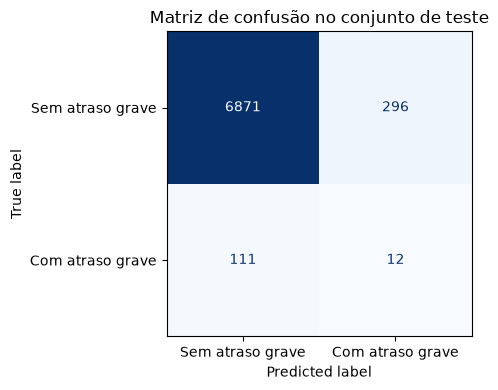

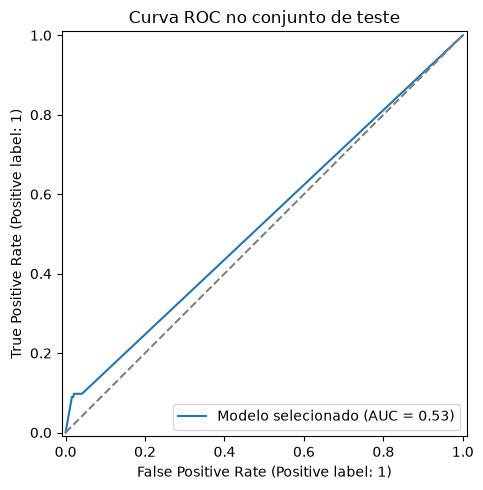

In [26]:
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Sem atraso grave", "Com atraso grave"],
    cmap="Blues", values_format="d", colorbar=False, ax=ax
)
ax.set_title("Matriz de confusão no conjunto de teste")
fig.tight_layout()
fig.savefig(FIGURES / "06_matriz_confusao.png", dpi=160, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_score, name="Modelo selecionado", ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_title("Curva ROC no conjunto de teste")
fig.tight_layout()
fig.savefig(FIGURES / "07_curva_roc.png", dpi=160, bbox_inches="tight")
plt.show()

**O que observei:** no teste por perfil, a ROC AUC foi 0,529 e a average precision foi 0,024. A curva fica próxima da linha de referência, indicando que a Árvore de Decisão tem dificuldade para separar perfis não vistos. A matriz detalha os erros; o ponto de corte padrão é 0,5.

## 4. Quais informações mais influenciaram o modelo


,Variável,Importância
2,numeric__DAYS_BIRTH,0.243783
3,numeric__DAYS_EMPLOYED,0.202520
1,numeric__AMT_INCOME_TOTAL,0.154827
0,numeric__CNT_CHILDREN,0.024490
5,numeric__FLAG_PHONE,0.023234
7,numeric__CNT_FAM_MEMBERS,0.022526
20,categorical__NAME_EDUCATION_TYPE_Higher education,0.019440
25,categorical__NAME_FAMILY_STATUS_Married,0.017283
27,categorical__NAME_FAMILY_STATUS_Single / not m...,0.015415
15,categorical__NAME_INCOME_TYPE_Pensioner,0.015029


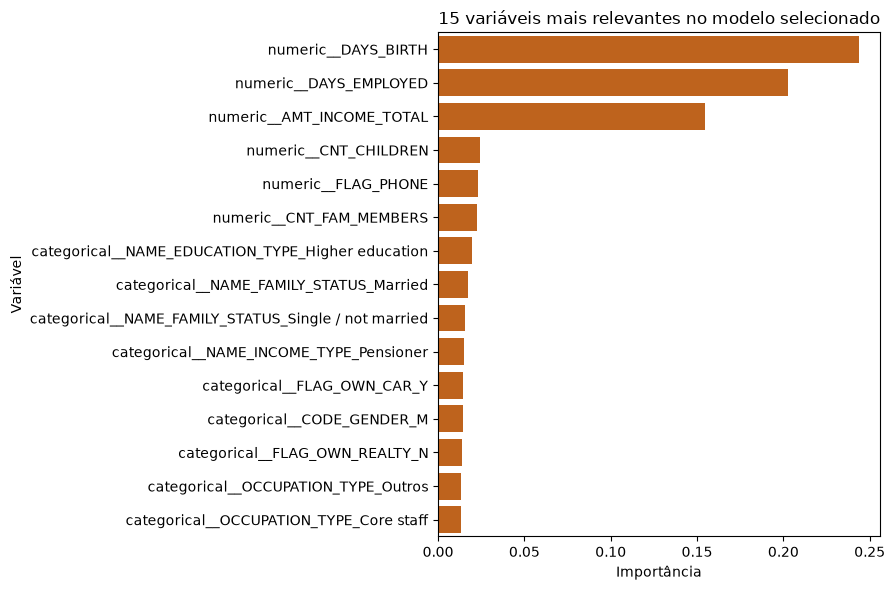

In [23]:
preprocessor = best_model.named_steps["preprocessor"]
classifier = best_model.named_steps["model"]
feature_names = preprocessor.get_feature_names_out()

if hasattr(classifier, "feature_importances_"):
    importances = classifier.feature_importances_
    criterio = "Importância"
else:
    importances = abs(classifier.coef_[0])
    criterio = "Coeficiente absoluto"

feature_importance = pd.DataFrame({
    "Variável": feature_names,
    criterio: importances,
}).sort_values(criterio, ascending=False)
display(feature_importance.head(15))

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=feature_importance.head(15), x=criterio, y="Variável", color="#d95f02", ax=ax)
ax.set_title("15 variáveis mais relevantes no modelo selecionado")
fig.tight_layout()
fig.savefig(FIGURES / "08_importancia_variaveis.png", dpi=160, bbox_inches="tight")
plt.show()

feature_importance.to_csv(METRICS / "importancia_variaveis.csv", index=False)

**O que observei:** idade, tempo de emprego e renda foram as variáveis mais usadas pela Árvore de Decisão. Isso não prova que causem o atraso grave; apenas foram úteis nas decisões do modelo nesta base.

## 5. O que isso pode significar para o banco

No teste com perfis não vistos, o modelo encontrou 12 dos 123 clientes com atraso grave (recall de 9,8%) e sinalizou 296 clientes sem atraso grave pela regra adotada. Entre os 308 clientes sinalizados, 12 tiveram atraso grave (precisão de 3,9%). Esse resultado é fraco para uma decisão automática. Os perfis idênticos com alvos diferentes mostram que as informações cadastrais não explicam sozinhas o comportamento de pagamento. Seria necessário acrescentar dados mais diretamente ligados ao histórico financeiro e definir, com o banco, quantos falsos alertas são aceitáveis.


## 6. Limitações

A auditoria encontrou 269 perfis cadastrais idênticos associados a alvos diferentes. Como o modelo recebe as mesmas características para esses clientes, não tem como distingui-los com as variáveis disponíveis. A avaliação por perfil evita que clientes com características iguais apareçam no treino e no teste, mas também é mais difícil: estima o desempenho em perfis novos, não em clientes de perfis que o modelo já conhece. O alvo é uma regra criada a partir dos atrasos observados e pode não representar todos os tipos de risco. Antes de uso prático, seriam necessários dados financeiros mais informativos, testes em outros períodos e avaliação de possíveis diferenças entre grupos de clientes.